In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import json
import pylab as plt
import pdb
import math
import os
from jlu.observe import skycalc
from microlens.jlu import munge 
from microlens.jlu import model_fitter, model
import shutil, os, sys
import scipy
import scipy.stats
from scipy.stats import chi2
from jlu.papers import lu_2019_lens
from astropy.table import Table
from jlu.util import fileUtil
from astropy.table import Table, Column, vstack
from astropy.io import fits
import matplotlib.ticker
import matplotlib.colors
from matplotlib.pylab import cm
from matplotlib.colors import Normalize, LogNorm
import mpl_toolkits
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.ticker import NullFormatter
from microlens.jlu import model_fitter, multinest_utils, multinest_plot, munge_ob150211, munge_ob150029, model
from matplotlib.colors import LinearSegmentedColormap, colorConverter
import pdb
import pickle
from scipy.stats import norm
import yaml
from flystar import plots
from flystar import analysis
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.wcs import WCS
from jlu.util import datetimeUtil as dtUtil
from datetime import datetime as dt

In [3]:
# Fontsize
plt.rc('font', size=17)

# Default matplotlib color cycles.
mpl_b = '#1f77b4'
mpl_o = '#ff7f0e'
mpl_g = '#2ca02c'
mpl_r = '#d62728'

In [32]:
phot_ast_fits = {'MB09260' : '/u/jlu/work/microlens/MB09260/a_2021_09_19/model_fits/moa_hst_phot_ast_gp/base_a/a0_',
                 'MB09260_split' : '/u/jlu/work/microlens/MB09260/a_2021_09_19/model_fits/moa_hst_phot_ast_gp/base_a/a0_split_',
                 'MB10364' : '/u/jlu/work/microlens/MB10364/a_2021_09_19/model_fits/moa_hst_phot_ast_adderr/base_a/a0_', # NO GP, TEMPORARY              
                 'OB110037' : '/u/jlu/work/microlens/OB110037/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_',
                 'OB110310' : '/u/jlu/work/microlens/OB110310/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_',
                 'OB110310_split' : '/u/jlu/work/microlens/OB110310/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/base_a/a0_split_',
                 'OB110462_el' : '/u/jlu/work/microlens/OB110462/a_2021_12_28/model_fits/ogle_hst_phot_ast/pspl/fixed_weight/a0_', # EQUAL LIKELIHOOD    
                 'OB110462_p' : '/u/jlu/work/microlens/OB110462/a_2021_07_08/model_fits/ogle_hst_phot_ast_gp/u0p_En_Nn/a0_',
                 'OB110462_new_dw_ast' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/hst_ast/base_a/a0_',
                 #'MB19284' : '/g2/scratch/jlu/microlens/MB19284/a_2024_08_29/model_fit/BSPL_base_a0_allDATA_Hobson_Weighted_noOM_dragon/a0_'
                 'MB19284' : '/g2/scratch/jlu/microlens/MB19284/a_2024_08_29/model_fit/BSPL_base_a0_allDATA_Hobson_Weighted_noOM_dragon/a0_'
                }
# From reanalysis
phot_fits = {'OB110462' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/ogle_hst_phot_gp/base_a/a0_'} # nominal fits                              
ast_fits = {'OB110462' : '/u/jlu/work/microlens/OB110462/a_2023_04_23/model_fits/hst_ast/base_a/a0_'}

mdir = '/u/jlu/work/microlens/'
mg2dir = '/g2/scratch/jlu/microlens/'
phot_2020_dir = {'kb200101' : mg2dir + 'KB200101/a_2025_09_10/model_fits/run_pspl_par_k_plot_things/',
                 'mb19284' : mdir + '',
                 'ob190017' : mg2dir + 'OB190017/a_2025_09_17/a0_',
                 'ob170019' : mg2dir + 'OB170019/a_2025_09_17/a0_', 
                 'ob170095' : mg2dir +  'OB170095/a_2025_09_17/a0_',
                 'ob230215' : '/u/mhuston/code/MAD/bagle_fits/OB230215/fits_2024_09_27/pspl_phot_par/b0_',
                 'ob240062' : '/u/mhuston/code/MAD/bagle_fits/OB240062/fits_2024_09_25/pspl_phot_par/b0_'}

In [25]:
# run directory
ob120169_dir = '/u/jlu/work/microlens/OB120169/a_2023_12_05/model_fits/120_phot_astrom_adderr/'
ob140613_dir = '/u/jlu/work/microlens/OB140613/a_2024_04_02/model_fits/phot_astro_EW/'
ob150029_dir = '/u/jlu/work/microlens/OB150029/a_2023_12_12/model_fits/120_fit_phot_astrom_parallax_aerr_ogle_keck/base_a/'
ob150211_dir = '/u/jlu/work/microlens/OB150211/a_2023_12_12/model_fits/120_phot_astrom_parallax_aerr_ogle_keck/'

# run id
ob120169_id = 'a1'
ob140613_id = 'a1'
ob150029_id = 'a1'
ob150211_id = 'a1'

mod_roots = {'ob120169': ob120169_dir + ob120169_id + '_',
             'ob140613': ob140613_dir + ob140613_id + '_',
             'ob150029': ob150029_dir + ob150029_id + '_',
             'ob150211': ob150211_dir + ob150211_id + '_',
             'mb19284':  phot_ast_fits['MB19284']}

In [26]:
pspl_ast_multiphot = {'ob120169': ob120169_dir + ob120169_id + '_',
             'ob140613': ob140613_dir + ob140613_id + '_',
             'ob140613_alt': ob140613_dir + ob140613_id + '_',
             'ob150029': ob150029_dir + ob150029_id + '_',
             'ob150211': ob150211_dir + ob150211_id + '_'}
pspl_ast_multiphot_mode = {'ob120169': 0,
                           'ob140613': 0,
                           'ob140613_alt': 1,
                           'ob150029': 0,
                           'ob150211': 0}

# Airmass + moon position

In [6]:
target_data = json.load(open('/u/mhuston/code/plot-airmass/target_coords.json'))
print([target_data['all_coords'][x] for x in target_data['run_targets']['Keck_AO_2025']])

[['17:53:57.68', '-28:34:21.6'], ['18:05:55.0600', '-30:20:12.9400'], ['18:20:20.3777', '-21:35:14.9']]


In [7]:
ra = "18:00:00"
dec = "-30:00:00"
months = np.array([8, 9])
days = np.array([1,1])
outdir = '/u/mhuston/work/prop_keck_2025b/'

Midnight: 2025-09-01 10:00:00.000
Sunrise  6.2   Sunset -5.4  (hours around midnight HST)
12-degr -4.6  12-degr  5.3  (hours around midnight HST)


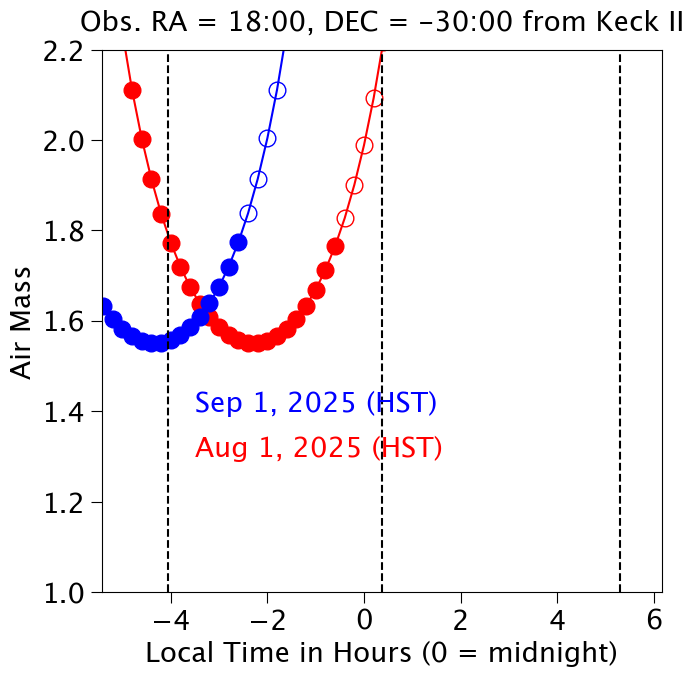

In [8]:
skycalc.plot_airmass(ra, dec, 2025, months, days, 'keck2', outfile=outdir + 'microlens_airmass_keck2_25B.png', 
                     date_idx=-1, proposal_cycle = 'B')

Day:  1   Moon Illum: 49.1   Moon Dist: 52.8
Day:  2   Moon Illum: 58.5   Moon Dist: 40.9
Day:  3   Moon Illum: 67.7   Moon Dist: 29.0
Day:  4   Moon Illum: 76.3   Moon Dist: 17.0
Day:  5   Moon Illum: 84.1   Moon Dist:  4.9
Day:  6   Moon Illum: 90.7   Moon Dist:  7.7
Day:  7   Moon Illum: 95.7   Moon Dist: 20.3
Day:  8   Moon Illum: 98.9   Moon Dist: 33.3
Day:  9   Moon Illum: 99.9   Moon Dist: 46.6
Day: 10   Moon Illum: 98.6   Moon Dist: 60.2
Day: 11   Moon Illum: 94.7   Moon Dist: 74.0
Day: 12   Moon Illum: 88.5   Moon Dist: 87.9
Day: 13   Moon Illum: 80.2   Moon Dist: 102.0
Day: 14   Moon Illum: 70.3   Moon Dist: 116.1
Day: 15   Moon Illum: 59.3   Moon Dist: 130.2
Day: 16   Moon Illum: 47.8   Moon Dist: 144.4
Day: 17   Moon Illum: 36.5   Moon Dist: 158.4
Day: 18   Moon Illum: 26.0   Moon Dist: 172.2
Day: 19   Moon Illum: 16.8   Moon Dist: 173.1
Day: 20   Moon Illum:  9.3   Moon Dist: 159.5
Day: 21   Moon Illum:  3.9   Moon Dist: 145.9
Day: 22   Moon Illum:  0.8   Moon Dist: 132.4


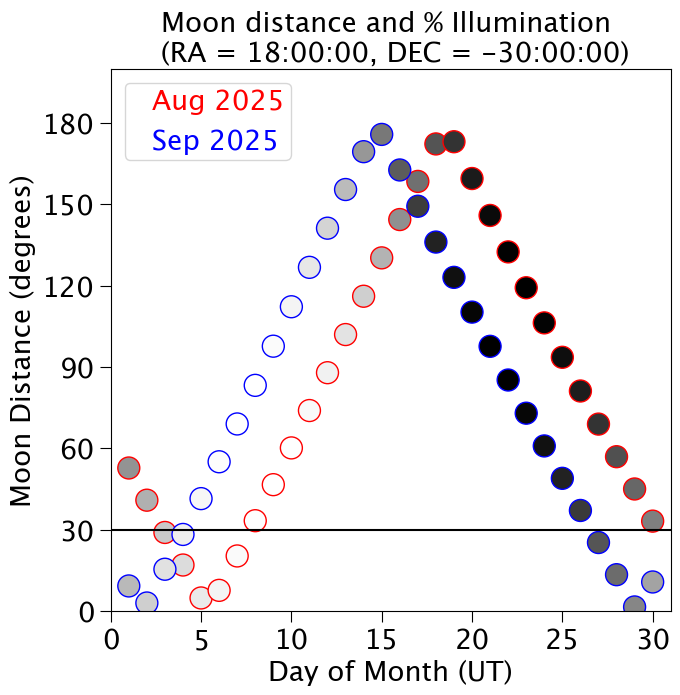

In [9]:
skycalc.plot_moon(ra, dec, 2025, months, outfile=outdir + 'microlens_moon_25B.png')

# Lens Masses

/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


***** WARNING: PHOTOMETRY DATA WILL NOT BE FIT BY <class 'bagle.model.PSPL_Astrom_Par_Param3'> *****


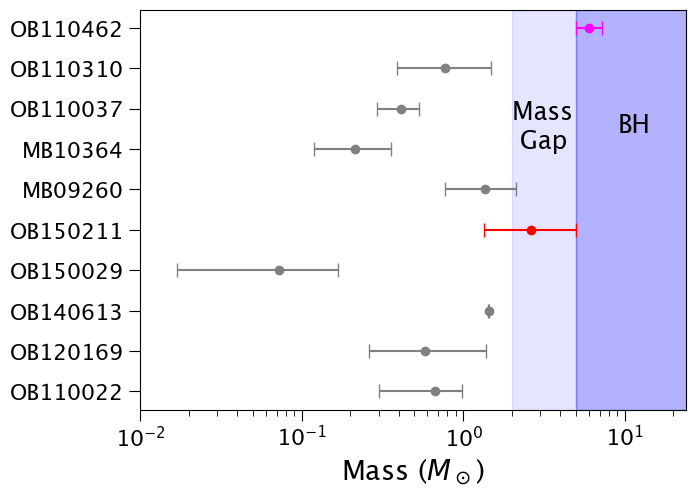

In [8]:
def get_med_1sig(samples, weights):
    # Calculate median, sigma lo, and sigma hi credible interval.                                                                                        
    sig1 = 0.682689
    sig1_lo = (1. - sig1) / 2.
    sig1_hi = 1. - sig1_lo
    med_vals = model_fitter.weighted_quantile(samples,
                                              [0.5, sig1_lo, sig1_hi],
                                              sample_weight=weights)
    # Switch from values to errors.                                                                                                                       
    med_vals[1] = med_vals[0] - med_vals[1]
    med_vals[2] = med_vals[2] - med_vals[0]

    return med_vals

def plot_mass_targets():
    bins_mL = np.logspace(-2,1.5,30)
    colors = {'ob110022': 'gray',
              'ob120169': 'gray',
              'ob140613': 'gray',
              'ob150029': 'gray',
              'ob150211': 'red',
              'ob170019': 'blue',
              'ob170095': 'blue',
              'ob190017': 'blue',
              'kb200101': 'blue',
              'MB09260' : 'gray',
              'MB10364' : 'gray',
              'OB110037' : 'gray',
              'OB110310' : 'gray',
              'OB110462' : 'magenta',
              'MB19284': 'blue'}
    hst_targets = ['MB09260', 'MB10364', 'OB110037', 'OB110310', 'OB110462'] 
    keck_targets = ['ob120169', 'ob140613', 'ob150029', 'ob150211']
    mL = {}
    weights = {}

    # Get data for plotting.
    for targ in hst_targets:
        if targ == 'OB110462':
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(ast_fits['OB110462'])
        else:
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(phot_ast_fits[targ])
        res_targ = fit_targ.load_mnest_results()
        mL[targ] = res_targ['mL']
        weights[targ] = res_targ['weights']

    for targ in keck_targets:
        fit_targ, dat_targ = lu_2019_lens.get_data_and_fitter(mod_roots[targ])
        res_targ = fit_targ.load_mnest_results()
        mL[targ] = res_targ['mL']
        weights[targ] = res_targ['weights']

    # MASSES ONLY.
    fig, ax1 = plt.subplots(1, 1, figsize=(7, 5))
    plt.subplots_adjust(left=0.2, bottom=0.18, top=0.98, right=0.98)

    name_list = []

    # OB110022... by hand.
    ax1.errorbar(0.67, 1, xerr=np.array([0.37, 0.32]).reshape(2,1), marker='o', capsize=5, color=colors['ob110022'])
    name_list.append('ob110022')

    for ii, targ in enumerate(keck_targets, start=2):
        mL_med, mL_lo1, mL_hi1 = get_med_1sig(mL[targ], weights[targ])
        name_list.append(targ)
        ax1.errorbar(mL_med, ii, xerr=np.array([mL_lo1, mL_hi1]).reshape(2,1), marker='o', capsize=5, color=colors[targ])

    for ii, targ in enumerate(hst_targets[:4], start=6):
        mL_med, mL_lo1, mL_hi1 = get_med_1sig(mL[targ], weights[targ])
        name_list.append(targ)
        ax1.errorbar(mL_med, ii, xerr=np.array([mL_lo1, mL_hi1]).reshape(2,1), marker='o', capsize=5, color=colors[targ])

    mL_med, mL_lo1, mL_hi1 = get_med_1sig(mL['OB110462'], weights['OB110462'])
    eb1 = ax1.errorbar(mL_med, 10, xerr=np.array([mL_lo1, mL_hi1]).reshape(2,1), marker='o', capsize=5, color=colors['OB110462'])
    name_list.append('OB110462')

    ax1.set_yticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
    ax1.set_yticklabels([x.upper() for x in name_list])
    ax1.set_xlabel('Mass ($M_\odot$)')
    ax1.set_xlim(bins_mL[0], bins_mL[-2])
    ax1.set_xscale('log')
    ax1.axvspan(2, 5, color='blue', alpha=0.1)
    ax1.axvspan(5, 100, color='blue', alpha=0.3)
    ax1.text(2, 7, 'Mass \n Gap', size=18)
    ax1.text(9, 7.4, 'BH', size=18)
    plt.savefig('masses_25B.png')

plot_mass_targets()

 # tE piE plots

/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


***** WARNING: PHOTOMETRY DATA WILL NOT BE FIT BY <class 'bagle.model.PSPL_Astrom_Par_Param3'> *****


ob140613 382.5393276649865 0.14214038239976784
ob230215 399.6930794535258 0.12564171754253817


/u/nsabrams/code/BAGLE_Microlensing/src/bagle/model_fitter.py:5460: UserWarning: The following kwargs were not used by contour: 'quantiles_2d'
  ax.contour(X2, Y2, H2.T, V, colors = color, **contour_kwargs, **kwargs)


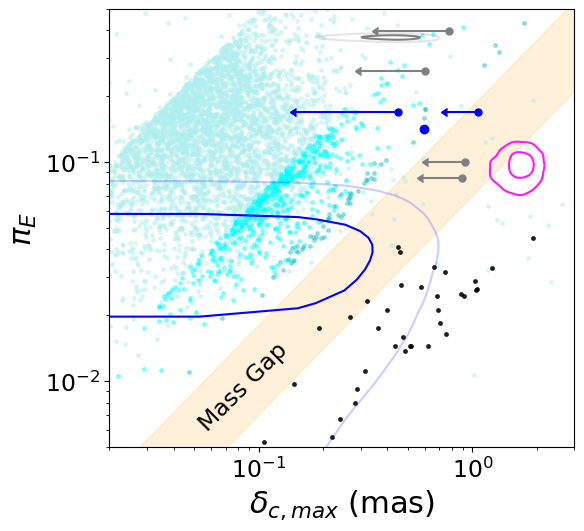

In [40]:
def piE_tE(fit_type = 'ast'):
    """
    Supports plotting for several different fit solutions:

    fit_type = 'ast'
        Keck + OGLE photometry, Keck astrometry
    fit_type = 'phot'
        OGLE photometry
    fit_type = 'multiphot'
        Keck + OGLE photometry
    """
    piE_tE_textsize = 22
    
    if fit_type == 'ast':
        data_dict = mod_roots
    if fit_type == 'phot':
        data_dict = lu_2019_lens.pspl_phot
    if fit_type == 'multiphot':
        data_dict = lu_2019_lens.pspl_multiphot

    ##########
    # !!! NOTE: CHOICE OF THE quantiles_2d HAS A LARGE EFFECT 
    # ON THE WAY THIS PLOT LOOKS !!!
    # Plot piE-tE 2D posteriors from OGLE photometry only fits.
    # Also plot PopSyCLE simulations simultaneously.
    ##########
    span = 0.999999426697
    smooth = 0.04
    quantiles_2d = None
    hist2d_kwargs = None
    labels = None
    label_kwargs = None
    show_titles = False 
    title_fmt = ".2f" 
    title_kwargs = None
    
    # Initialize values.
    if label_kwargs is None:
        label_kwargs = dict()
    if title_kwargs is None:
        title_kwargs = dict()
    if hist2d_kwargs is None:
        hist2d_kwargs = dict()

    # Dictionary of dictionaries containing the tE and piE
    # label position for each of the text labels.
    # WARNING: THE 'PHOT' AND 'AST' ARE THE SAME FOR THE NEW
    # TARGETS... THEY ARE JUST PHOT THOUGH.
    label_pos = {'phot': {'ob120169': [150, 0.01],
                          'ob140613': [170, 0.1],
                          'ob150029': [150, 0.2],
                          'ob150211': [35, 0.04],
                          'ob170019': [0, 0.04],
                          'ob170095': [0, 0.04],
                          'ob190017': [0, 0.04],
                          'kb200101': [0, 0],
                          'ob230215': [400, 0.1],
                          'ob240062': [220, 0.03]},
                 'ast':  {'ob120169': [45, 0.12],
                          'ob140613': [250, 0.16],
                          'ob150029': [40, 0.22],
                          'ob150211': [140, 0.01],
                          'ob170019': [120, 0.045],
                          'ob170095': [30, 0.04],
                          'ob190017': [70, 0.21],
                          'kb200101': [120, 0.06],
                          'MB19284' : [340, 0.08],
                          'ob230215': [420, 0.115],
                          'ob240062': [220, 0.025]}}

    label_pos_ast = {'ob120169': [0.006, 0.06],
                     'ob140613': [0.04, 0.145],
                     'ob150029': [0.02, 0.25],
                     'ob150211': [0.03, 0.012]}

    colors = {'ob120169': 'blue',
              'ob140613': 'blue',
              'ob140613_alt': 'orange',
              'ob150029': 'blue',
              'ob150211': 'blue',
              'ob170019': 'blue',
              'ob170095': 'blue',
              'ob190017': 'green',
              'kb200101': 'green',
              'ob230215': 'green',
              'ob240062': 'green',
              'MB09260' : 'gray',
              'MB10364' : 'gray',
              'OB110037' : 'gray',
              'OB110310' : 'gray',
              'OB110462' : 'magenta',
              'MB19284': 'green'}

    #manual_pts = {}

    # Set defaults.
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    hist2d_kwargs['levels'] = hist2d_kwargs.get('levels', quantiles_2d)

#    model_fitter.contour2d_alpha(data['tE'], data['piE'], span=[span, span], quantiles_2d=quantiles_2d,
#                                 ax=axes, smooth=[sy, sx], color='blue',
#                                 **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
#    axes.text(300, 0.025, 'MB19284', color='blue')


    targets = ['ob120169', 'ob140613', 'ob150029', 'ob150211'] #'ob140613_alt',
    hst_targets = ['MB09260', 'MB10364', 'OB110037', 'OB110310', 'OB110462']
    new_targets = ['ob170019', 'ob170095', 'ob190017', 'kb200101', 'ob230215','ob240062']
    label_targets = [ 'ob230215', 'ob240062', 'ob190017', 'kb200101'] #, 'OB110462']
    tE = {}
    piE = {}
    theta_E = {}
    weights = {}

    for targ in hst_targets + ['MB19284']:
        if targ == 'OB110462':
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(ast_fits['OB110462'])
        else:
            fit_targ, dat_targ = multinest_utils.get_data_and_fitter(phot_ast_fits[targ])

        res_targ = fit_targ.load_mnest_results()

        tE[targ] = res_targ['tE']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        theta_E[targ] = 10**res_targ['log10_thetaE']
        weights[targ] = res_targ['weights']

    for targ in targets:
        fitter, data = lu_2019_lens.get_data_and_fitter(pspl_ast_multiphot[targ])
        #fitter.separate_modes()
#        stats_ast, data_ast, mod_ast = lu_2019_lens.load_summary_statistics(lu_2019_lens.pspl_ast_multiphot[targ])
        tab_list = fitter.load_mnest_modes()
        mode = pspl_ast_multiphot_mode[targ]
        fit_targ, dat_targ = multinest_utils.get_data_and_fitter(pspl_ast_multiphot[targ])

        res_targ = tab_list[mode]
        
#        res_targ = fit_targ.load_mnest_results(remake_fits=True)
#        res_targ = fit_targ.load_mnest_modes()
#        res_targ = res_targ[0]
#
        tE[targ] = res_targ['tE']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        try:
            theta_E[targ] = res_targ['thetaE_amp']
        except:
            theta_E[targ] = res_targ['thetaE']
        weights[targ] = res_targ['weights']

    for targ in new_targets:
        fit_targ, dat_targ = lu_2019_lens.get_data_and_fitter(phot_2020_dir[targ])
        
        res_targ = fit_targ.load_mnest_modes()
        smy_targ = fit_targ.load_mnest_summary()

        # Get rid of the global mode in the summary table.
        smy_targ = smy_targ[1:]

        # Find which solution has the max likelihood.
        mdx = smy_targ['maxlogL'].argmax()
        res_targ = res_targ[0]
        smy_targ = smy_targ
        tE[targ] = res_targ['tE']
        piE[targ] = np.hypot(res_targ['piE_E'], res_targ['piE_N'])
        weights[targ] = res_targ['weights']

    # Plot the piE-tE 2D posteriors.
#    plt.close(1)
    fig = plt.figure(1, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)
    sx = smooth
    sy = smooth

    hist2d_kwargs['fill_contours'] = hist2d_kwargs.get('fill_contours', False)
    hist2d_kwargs['plot_contours'] = hist2d_kwargs.get('plot_contours', True)

    for targ in targets + new_targets + ['MB09260', 'MB10364', 'OB110037', 'OB110310', 'MB19284']:
        model_fitter.contour2d_alpha(tE[targ], piE[targ], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights[targ], ax=axes, smooth=[sy, sx], color=colors[targ],
                                     **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
        if targ[:4]=='ob14' or targ=='ob230215':
            print(targ, np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]))
            #manual_pts[targ] = (np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]))
            plt.plot(np.average(tE[targ], weights=weights[targ]), np.average(piE[targ], weights=weights[targ]), 'o', color=colors[targ])

        
    hist2d_kwargs['plot_contours'] = hist2d_kwargs.get('plot_contours',
                                                       False)
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    model_fitter.contour2d_alpha(tE['OB110462'], piE['OB110462'], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights['OB110462'], ax=axes, smooth=[sy, sx], color=colors['OB110462'],
                                 contour_kwargs={'alpha' : 0.9}, plot_density=False, sigma_levels=[1, 2])

    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.2)


    for targ in label_targets + ['MB19284']:
        axes.text(label_pos[fit_type][targ][0], label_pos[fit_type][targ][1],
                      targ.upper(), color=colors[targ], ha='left')

    # OB110022 from Lu+16.
    piEE_110022 = -0.393
    piEN_110022 = -0.071
    piE_110022 = np.hypot(piEE_110022, piEN_110022)
    tE_110022 = 61.4

    dcmax_110022 = 2.19/np.sqrt(8)
    dcmax_110022_pe = 1.06/np.sqrt(8)
    dcmax_110022_me = 1.17/np.sqrt(8)

    # MB19284 from Dave Bennett.
    piEE_19284 = -0.06339
    piEN_19284 = 0.05600
    piE_19284 = np.hypot(piEE_19284, piEN_19284)
    tE_19284 = 648.454

    # Plotting OB110022 and MB19284.
#    plt.scatter(tE_110022, piE_110022, marker = 'o', s = 30, color='indigo')
#    axes.text(18, 0.38, 'OB110022', color='indigo')
    plt.scatter(tE_110022, piE_110022, marker = 's', s = 40, color='gray')
    plt.scatter(129.4, 0.04, marker = 's', s = 40, color='blue')
    plt.plot(906, 0.102, 'o', color='green')
    
    t = Table.read('/u/nsabrams/work/papers/binary_popsycle/data/all_fields_Srun_EWS.fits')
    lmag = t['ubv_I_app_L']
    smag = t['ubv_I_app_S']
    

    bh_idx = np.where(t['rem_id_L'] == 103)[0]
    ns_idx = np.where(t['rem_id_L'] == 102)[0]
    wd_idx = np.where(t['rem_id_L'] == 101)[0]
    st_idx = np.where(t['rem_id_L'] == 0)[0]

    u0_arr = t['u0']
    thetaE_arr = t['theta_E']
    # Stores the maximum astrometric shift
    final_delta_arr = np.zeros(len(u0_arr))
    
    # Stores the lens-source separation corresponding
    # to the maximum astrometric shift
    final_u_arr = np.zeros(len(u0_arr))

    # Sort by whether the maximum astrometric shift happens
    # before or after the maximum photometric amplification
    big_idx = np.where(u0_arr > np.sqrt(2))[0]
    small_idx = np.where(u0_arr <= np.sqrt(2))[0]

    # Flux ratio of lens to source (and make it 0 if dark lens)
    g_arr = 10**(-0.4 * (lmag - smag))
    g_arr = np.nan_to_num(g_arr.filled(np.nan))

    for i in np.arange(len(u0_arr)):
        g = g_arr[i] 
        thetaE = thetaE_arr[i]    
        # Try all values between u0 and sqrt(2) to find max 
        # astrometric shift
        if u0_arr[i] < np.sqrt(2):
            u_arr = np.linspace(u0_arr[i], np.sqrt(2), 100)
            delta_arr = np.zeros(len(u_arr))
            for j in np.arange(len(u_arr)):
                u = u_arr[j] 
                numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
                denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
                delta = (u * thetaE/(1 + g)) * (numer/denom)
                delta_arr[j] = delta
            max_idx = np.argmax(delta_arr)
            final_delta_arr[i] = delta_arr[max_idx]
            final_u_arr[i] = u_arr[max_idx]
        # Maximum astrometric shift will occur at sqrt(2)
        if u0_arr[i] > np.sqrt(2):
            u = u0_arr[i]
            numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
            denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
            delta = (u * thetaE/(1 + g)) * (numer/denom)
            final_delta_arr[i] = delta
            final_u_arr[i] = u

    axes.scatter(t['t_E'][st_idx], t['pi_E'][st_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'paleturquoise')
    axes.scatter(t['t_E'][wd_idx], t['pi_E'][wd_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'aqua')
    axes.scatter(t['t_E'][ns_idx], t['pi_E'][ns_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'tab:cyan')
    axes.scatter(t['t_E'][bh_idx], t['pi_E'][bh_idx],
                 alpha = 0.8, marker = '.', s = 25, 
                 color = 'black')

    # Trickery to make the legend darker
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'Star', color = 'paleturquoise')
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25,
                 label = 'WD', color = 'aqua')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'NS', color = 'tab:cyan')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'BH', color = 'black')

    axes.set_xlim(10, 1000)
    axes.set_ylim(0.005, 0.5)
    axes.set_xlabel('$t_E$ (days)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.legend(loc=3)
    plt.savefig('piE_tE_26A.png', bbox_inches='tight')
    plt.close()

    # Plot the deltac-piE 2D posteriors.
#    plt.close(2)
    fig = plt.figure(2, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)

    axes.errorbar(dcmax_110022, piE_110022, 
                   xerr = np.array([[dcmax_110022_me], [dcmax_110022_pe]]), 
                   fmt = 'o', color = 'gray', markersize = 5,
                   xuplims = True)
#    axes.text(0.5, 0.3, 'OB110022', color='gray')

    # MB09260, MB10364, OB11030
    axes.errorbar(0.6, 0.26, xerr = np.array([[0.3], [0.3]]), 
                  fmt = 'o', color = 'gray', markersize = 5,
                  xuplims = True)

    axes.errorbar(0.92, 0.1, xerr = np.array([[0.3], [0.3]]), 
                   fmt = 'o', color = 'gray', markersize = 5,
                   xuplims = True)

    axes.errorbar(0.89, 0.085, xerr = np.array([[0.3], [0.3]]), 
                   fmt = 'o', color = 'gray', markersize = 5,
                   xuplims = True)

    # ob120169 and ob150029
    axes.errorbar(1.06, 0.17, xerr = np.array([[0.3], [0.3]]), 
                  fmt = 'o', color = 'blue', markersize = 5,
                  xuplims = True)

    axes.errorbar(0.45, 0.17, xerr = np.array([[0.3], [0.3]]), 
                   fmt = 'o', color = 'blue', markersize = 5,
                  xuplims = True)

    for targ in ['ob140613','ob150211', 'OB110037']: #'ob140613_alt', 
        model_fitter.contour2d_alpha(theta_E[targ]/np.sqrt(8), piE[targ], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights[targ], ax=axes, smooth=[sy, sx], color=colors[targ],
                                 **hist2d_kwargs, plot_density=False, sigma_levels=[1, 2])
        if targ[:4]=='ob14':
            plt.plot(np.average(theta_E[targ]/np.sqrt(8), weights=weights[targ]), np.average(piE[targ], weights=weights[targ]), 'o', color=colors[targ])
            #pass

    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.8)
    

    model_fitter.contour2d_alpha(theta_E['OB110462']/np.sqrt(8), piE['OB110462'], span=[span, span], quantiles_2d=quantiles_2d,
                                 weights=weights['OB110462'], ax=axes, smooth=[sy, sx], color=colors['OB110462'],
                                 contour_kwargs={'alpha' : 0.9}, plot_density=False, sigma_levels=[1, 2])
    hist2d_kwargs['alpha'] = hist2d_kwargs.get('alpha', 0.2)
 

    xarr = np.linspace(0.001, 4, 1000)
    axes.fill_between(xarr, xarr*0.18, xarr*0.07, alpha=0.15, color='orange')
    axes.text(0.05, 0.006, 'Mass Gap', rotation=45)

    axes.scatter(final_delta_arr[st_idx], t['pi_E'][st_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'paleturquoise')
    axes.scatter(final_delta_arr[wd_idx], t['pi_E'][wd_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'aqua')
    axes.scatter(final_delta_arr[ns_idx], t['pi_E'][ns_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'tab:cyan')
    axes.scatter(final_delta_arr[bh_idx], t['pi_E'][bh_idx], 
                  alpha = 0.8, marker = '.', s = 25,
                  c = 'black')

    axes.set_xlabel('$\delta_{c,max}$ (mas)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.set_xlim(0.02, 3)
    axes.set_ylim(0.005, 0.5)
    plt.savefig('piE_deltac_26A.png', bbox_inches='tight')
    plt.show()
piE_tE()

In [31]:
import pdb
pdb.pm()

> /var/folders/kl/v34p_bsn4mb5l5yt_y727tgm00011f/T/ipykernel_31763/880072305.py(161)piE_tE()
    159         # Find which solution has the max likelihood.
    160         mdx = smy_targ['maxlogL'].argmax()
--> 161         res_targ = res_targ[0]
    162         smy_targ = smy_targ
    163         tE[targ] = res_targ['tE']



ipdb>  fit_targ.load_mnest_modes()


No modes files! Did you run multinest_utils.separate_mode_files yet?
[]


ipdb>  q


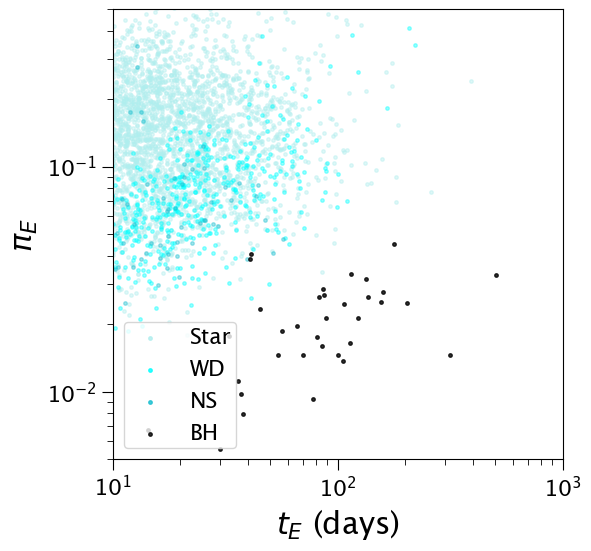

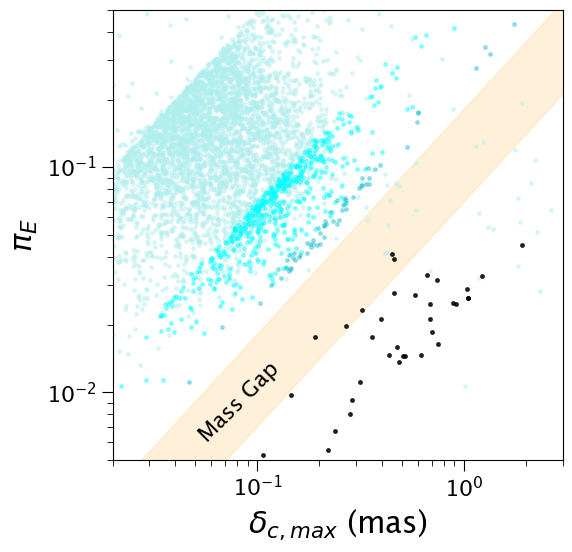

In [6]:
def piE_tE_plain(fit_type = 'ast'):
    """
    Supports plotting for several different fit solutions:

    fit_type = 'ast'
        Keck + OGLE photometry, Keck astrometry
    fit_type = 'phot'
        OGLE photometry
    fit_type = 'multiphot'
        Keck + OGLE photometry
    """
    piE_tE_textsize = 22

    # Plot the piE-tE 2D posteriors.
    fig = plt.figure(1, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)
    
    t = Table.read('/u/nsabrams/work/papers/binary_popsycle/data/all_fields_Srun_EWS.fits')
    lmag = t['ubv_I_app_L']
    smag = t['ubv_I_app_S']
    

    bh_idx = np.where(t['rem_id_L'] == 103)[0]
    ns_idx = np.where(t['rem_id_L'] == 102)[0]
    wd_idx = np.where(t['rem_id_L'] == 101)[0]
    st_idx = np.where(t['rem_id_L'] == 0)[0]

    u0_arr = t['u0']
    thetaE_arr = t['theta_E']
    # Stores the maximum astrometric shift
    final_delta_arr = np.zeros(len(u0_arr))
    
    # Stores the lens-source separation corresponding
    # to the maximum astrometric shift
    final_u_arr = np.zeros(len(u0_arr))

    # Sort by whether the maximum astrometric shift happens
    # before or after the maximum photometric amplification
    big_idx = np.where(u0_arr > np.sqrt(2))[0]
    small_idx = np.where(u0_arr <= np.sqrt(2))[0]

    # Flux ratio of lens to source (and make it 0 if dark lens)
    g_arr = 10**(-0.4 * (lmag - smag))
    g_arr = np.nan_to_num(g_arr.filled(np.nan))

    for i in np.arange(len(u0_arr)):
        g = g_arr[i] 
        thetaE = thetaE_arr[i]    
        # Try all values between u0 and sqrt(2) to find max 
        # astrometric shift
        if u0_arr[i] < np.sqrt(2):
            u_arr = np.linspace(u0_arr[i], np.sqrt(2), 100)
            delta_arr = np.zeros(len(u_arr))
            for j in np.arange(len(u_arr)):
                u = u_arr[j] 
                numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
                denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
                delta = (u * thetaE/(1 + g)) * (numer/denom)
                delta_arr[j] = delta
            max_idx = np.argmax(delta_arr)
            final_delta_arr[i] = delta_arr[max_idx]
            final_u_arr[i] = u_arr[max_idx]
        # Maximum astrometric shift will occur at sqrt(2)
        if u0_arr[i] > np.sqrt(2):
            u = u0_arr[i]
            numer = 1 + g * (u**2 - u * np.sqrt(u**2 + 4) + 3)
            denom = u**2 + 2 + g * u * np.sqrt(u**2 + 4)
            delta = (u * thetaE/(1 + g)) * (numer/denom)
            final_delta_arr[i] = delta
            final_u_arr[i] = u

    axes.scatter(t['t_E'][st_idx], t['pi_E'][st_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'paleturquoise')
    axes.scatter(t['t_E'][wd_idx], t['pi_E'][wd_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'aqua')
    axes.scatter(t['t_E'][ns_idx], t['pi_E'][ns_idx], 
                 alpha = 0.4, marker = '.', s = 25, 
                 color = 'tab:cyan')
    axes.scatter(t['t_E'][bh_idx], t['pi_E'][bh_idx],
                 alpha = 0.8, marker = '.', s = 25, 
                 color = 'black')

    # Trickery to make the legend darker
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'Star', color = 'paleturquoise')
    axes.scatter(0.01, 100, 
                 alpha = 0.8, marker = '.', s = 25,
                 label = 'WD', color = 'aqua')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'NS', color = 'tab:cyan')
    axes.scatter(0.01, 100,
                 alpha = 0.8, marker = '.', s = 25, 
                 label = 'BH', color = 'black')

    axes.set_xlim(10, 1000)
    axes.set_ylim(0.005, 0.5)
    axes.set_xlabel('$t_E$ (days)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.legend(loc=3)
    plt.savefig('piE_tE_plain.png', bbox_inches='tight')
    #plt.close()

    # Plot the deltac-piE 2D posteriors.
#    plt.close(2)
    fig = plt.figure(2, figsize=(6,6))
    plt.clf()
    axes = plt.gca()
    plt.subplots_adjust(bottom=0.15)


    xarr = np.linspace(0.001, 4, 1000)
    axes.fill_between(xarr, xarr*0.18, xarr*0.07, alpha=0.15, color='orange')
    axes.text(0.05, 0.006, 'Mass Gap', rotation=45)

    axes.scatter(final_delta_arr[st_idx], t['pi_E'][st_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'paleturquoise')
    axes.scatter(final_delta_arr[wd_idx], t['pi_E'][wd_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'aqua')
    axes.scatter(final_delta_arr[ns_idx], t['pi_E'][ns_idx], 
                  alpha = 0.4, marker = '.', s = 25,
                  c = 'tab:cyan')
    axes.scatter(final_delta_arr[bh_idx], t['pi_E'][bh_idx], 
                  alpha = 0.8, marker = '.', s = 25,
                  c = 'black')

    axes.set_xlabel('$\delta_{c,max}$ (mas)', fontsize=piE_tE_textsize)
    axes.set_ylabel('$\pi_E$', fontsize=piE_tE_textsize)
    axes.set_xscale('log')
    axes.set_yscale('log')
    axes.set_xlim(0.02, 3)
    axes.set_ylim(0.005, 0.5)
    plt.savefig('piE_deltac_plain.png', bbox_inches='tight')
    plt.show()
piE_tE_plain()

/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3462: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/opt/mambaforge3/envs/astro/lib/python3.11/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


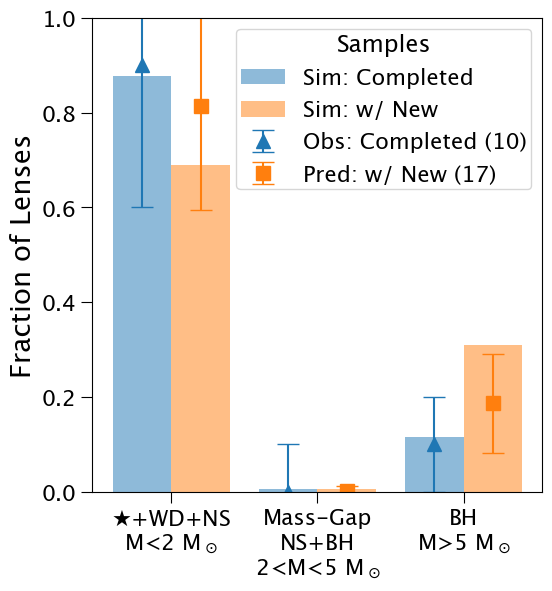

In [249]:
def plot_prob_v_mass():
    #t1 = Table.read('/u/casey/scratch/papers/microlens_2019/popsycle_rr_files/Mock_EWS_v2_NEW_DELTAM.fits')
    #t2 = Table.read('/g2/scratch/casey/papers/hst_sahu_2020/sub1_files/OB110462_Mock_EWS_v2.fits')
    #t_orig = vstack([t1, t2])

    t_orig = Table.read('/u/nsabrams/work/papers/binary_popsycle/data/all_fields_Srun_EWS.fits')

    # Make 3 bins:
    # First bin is all objects below 2 Msun 
    # Second bin is all dark objects above 2 Msun and below 5 Msun
    # Third bin is all dark objects above 5 Msun.
    # We will compare PopSyCLE vs. OUR observed probablilities

    # First trim out everything with tE < 60 days. That is our lowest object.
    tdx = np.where(t_orig['t_E'] > 60)[0]
    t = t_orig[tdx]
    
    # Estimate fractions for complete sample
    idx1 = np.where(t['mass_L'] < 2)[0]
    idx2 = np.where((t['mass_L'] >= 2) & (t['mass_L'] < 2) & (t['rem_id_L'] > 100))[0]
    idx3 = np.where((t['mass_L'] >= 5) & (t['rem_id_L'] > 100))[0]

    m_mean = np.array([np.median(t['mass_L'][idx1]),
                       np.median(t['mass_L'][idx2]), 
                       np.median(t['mass_L'][idx3])])
    if np.isnan(m_mean[1]):
        m_mean[1] = 0.5 * (5 - 1.3)

    prob = np.array([float(len(idx1)),
                     float(len(idx2)),
                     float(len(idx3))])
    prob /= len(t)

    # Estimate fractions for new sample (tE > 105 days)
    tdx_120 = np.where(t_orig['t_E'] > 120)[0]
    t_120 = t_orig[tdx_120]
    
    idx1_120 = np.where((t_120['t_E'] > 105) & (t_120['mass_L'] < 2))[0]
    idx2_120 = np.where((t_120['t_E'] > 105) & (t_120['mass_L'] >= 2) &
                            (t_120['mass_L'] < 2) & (t_120['rem_id_L'] > 100))[0]
    idx3_120 = np.where((t_120['t_E'] > 105) & (t_120['mass_L'] >= 5) &
                            (t_120['rem_id_L'] > 100))[0]

    m_mean_120 = np.array([np.median(t_120['mass_L'][idx1_120]),
                           np.median(t_120['mass_L'][idx2_120]), 
                           np.median(t_120['mass_L'][idx3_120])])
    if np.isnan(m_mean_120[1]):
        m_mean_120[1] = 0.5 * (5 + 2)
        
    prob_120 = np.array([float(len(idx1_120)),
                         float(len(idx2_120)),
                         float(len(idx3_120))])
    prob_120 /= len(t_120)

    zdx = np.where(prob == 0)[0]
    zdx_120 = np.where(prob_120 == 0)[0]
    prob[zdx] = 0.005
    prob_120[zdx_120] = 0.005

    # Make the bar widths and central locations... same for all.
    # m_mid   = np.array([1, 0.5 * (5 + 2), 0.5 * (16 + 5)])
    # m_width = np.array([2, (5 - 2), (16 - 5)])
    m_mid   = np.array([1, 2, 3])
    m_width = np.array([0.4, 0.4, 0.4])

    # Observed probabilities
    prob_obs = np.array([9, 0, 1], dtype=float)
    n_tot = np.sum(prob_obs)
    prob_obs_err = prob_obs**0.5
    prob_obs_err[prob_obs_err == 0] = 1
    prob_obs /= n_tot
    prob_obs_err /= n_tot

    # Predicted observed probabilities with slightly over twice the sample size
    # and tE > 105 days.
    # new sample is 9 new targets + 10 completed targets
    # probability is existing detections in the 10 + PopSyCLE predicted for the 9 new
    n_tot_120 = n_tot + 7
    prob_obs_120 = (prob_obs * n_tot) + (prob_120 * (n_tot_120 - n_tot))
    prob_obs_err_120 = prob_obs_120**0.5
    prob_obs_err_120[prob_obs_err_120 == 0] = 1
    prob_obs_120 /= n_tot_120
    prob_obs_err_120 /= n_tot_120

    # Multiply all the probabilities by the sample size.
    # prob *= 10
    # prob_120 *= 20
    # prob_obs *= 10
    # prob_obs_120 *= 20
    # prob_obs_err *= 10
    # prob_obs_err_120 *= 20
    
    plt.figure(1, figsize=(6,6))
    plt.clf()
    plt.subplots_adjust(bottom=0.16, top=0.95)
    # plt.plot(m_mean, prob, label='PopSyCLE: Completed Sample')
    # plt.plot(m_mean_120, prob_120, label='PopSyCLE: New Sample')
    plt.bar(m_mid, prob, width=m_width,
                label='Sim: Completed',
                alpha=0.5)
    plt.bar(m_mid + m_width, prob_120, width=m_width,
                label='Sim: w/ New',
                alpha=0.5)
    plt.errorbar(m_mid, prob_obs, yerr=prob_obs_err,
                     label=f'Obs: Completed ({n_tot:.0f})',
                     ls='none', marker='^', ms=10, capsize=8)
    plt.errorbar(m_mid + m_width, prob_obs_120, yerr=prob_obs_err_120,
                     label=f'Pred: w/ New ({n_tot_120:.0f})',
                     ls='none', marker='s', ms=10, capsize=8)
    # plt.legend(fontsize=13, title='Samples', title_fontsize=14)
    plt.legend(title='Samples')

    tick_labels = (r'$\bigstar$+WD+NS' + '\nM<2 M$_\odot$', 'Mass-Gap\nNS+BH\n2<M<5 M$_\odot$', 'BH\nM>5 M$_\odot$')
    plt.xticks(m_mid+(m_width/2), tick_labels)

    # plt.text(m_mid[0]-1, 0.1, tick_labels[0], fontsize=10)
    # plt.text(m_mid[1]-1, 0.1, tick_labels[1], fontsize=10)
    # plt.text(m_mid[2]-3, 0.1, tick_labels[2], fontsize=10)
    
    plt.ylim(0, 1)
    # plt.xlim(0, 15)

    # plt.xlabel('Lens Mass (M$_\odot$)')
    plt.ylabel('Fraction of Lenses')

    plt.savefig('prob_v_mass.png', bbox_inches='tight')
    
    return
plot_prob_v_mass()

# phot/ast curves

In [13]:
def plot_3panel(data, mod, tab, outfile, target, r_min_k=None, ast2 = False, min_max_ast_time = None, min_max_phot_time = None,
               inset_mass=False, mass_range=None):
    """
    ast2 : bool, optional
        True if there are two astrometric datasets

    min_max_ast_time : tuple or None, optional
        tuple of min and max times to plot on astrometric plot in MJD.
        None by default.
    
    """
    # Calculate the model on a similar timescale to the data.
    tmax = np.max(np.append(data['t_phot1'], data['t_phot2'])) + 90.0
    if ast2:
        t_ast = np.append(data['t_ast1'], data['t_ast2'])
        if min_max_ast_time is not None:
            t_mod_ast = np.arange(min_max_ast_time[0], min_max_ast_time[1], 2)
        else:
            t_mod_ast = np.arange(t_ast.min() - 180.0, tmax, 2)
        t_mod_ast1 = np.arange(data['t_ast1'].min() - 180.0, tmax, 2)
        t_mod_ast2 = np.arange(data['t_ast2'].min() - 180.0, tmax, 2)
    else:
        t_ast = data['t_ast1']
        if min_max_ast_time is not None:
            t_mod_ast = np.arange(min_max_ast_time[0], min_max_ast_time[1], 2)
        else:
            t_mod_ast = np.arange(data['t_ast1'].min() - 180.0, tmax, 2)
    t_mod_pho = np.arange(data['t_phot1'].min(), tmax, 0.1)

    # Get the linear motion curves for the source (includes parallax)
    p_unlens_mod = mod.get_astrometry_unlensed(t_mod_ast)
    p_unlens_mod_at_ast = mod.get_astrometry_unlensed(data['t_ast1'])
    if ast2:
        p_unlens_mod_at_ast1 = mod.get_astrometry_unlensed(data['t_ast1'])
        p_unlens_mod_at_ast2 = mod.get_astrometry_unlensed(data['t_ast2'])
    

    # Get the lensed motion curves for the source
    p_lens_mod = mod.get_astrometry(t_mod_ast)
    p_lens_mod_at_ast = mod.get_astrometry(data['t_ast1'])
    if ast2:
        p_lens_mod_at_ast1 = mod.get_astrometry(data['t_ast1'])
        p_lens_mod_at_ast2 = mod.get_astrometry(data['t_ast2'])

    # Geth the photometry
    m_lens_mod = mod.get_photometry(t_mod_pho, filt_idx=0)
    m_lens_mod_at_phot1 = mod.get_photometry(data['t_phot1'], filt_idx=0)
    m_lens_mod_at_phot2 = mod.get_photometry(data['t_phot2'], filt_idx=1)

    # Calculate the delta-mag between R-band and K-band from the
    # flat part at the end.
    tidx = np.argmin(np.abs(data['t_phot1'] - data['t_ast1'][-1]))
    if r_min_k == None:
        r_min_k = data['mag1'][tidx] - data['mag2'][-1]
    print('r_min_k = ', r_min_k)

    # Plotting        
    # plt.close(3)
    plt.figure(3, figsize=(14, 4))
    plt.clf()

    pan_wid = 0.22
    pan_pad = 0.09
    fig_pos = np.arange(0, 3) * (pan_wid + pan_pad) + 1.5*pan_pad

    plt.figtext(0.25*pan_pad, 0.55, target.upper(), rotation='vertical',
                    fontweight='bold', fontsize=20,
                    va='center', ha='center')

    # Brightness vs. time
    fm1 = plt.gcf().add_axes([fig_pos[0], 0.36, pan_wid, 0.6])
    fm2 = plt.gcf().add_axes([fig_pos[0], 0.18, pan_wid, 0.2])
    fm1.errorbar(data['t_phot1'], data['mag1'], yerr=data['mag_err1'],
                 color = mpl_b, fmt='.', alpha=0.05)
    # fm1.errorbar(data['t_phot2'], data['mag2'] + r_min_k, yerr=data['mag_err2'],
    #              fmt='k.', alpha=0.9)
    fm1.plot(t_mod_pho, m_lens_mod, 'r-')
    fm2.errorbar(data['t_phot1'], data['mag1'] - m_lens_mod_at_phot1, yerr=data['mag_err1'],
                 color = mpl_b, fmt='.', alpha=0.05)
    # fm2.errorbar(data['t_phot2'], data['mag2'] + r_min_k - m_lens_mod_at_phot2, yerr=data['mag_err2'],
    #              fmt='k.', alpha=0.9)
#    fm2.set_yticks(np.array([0.0, 0.2]))
    fm1.yaxis.set_major_locator(plt.MaxNLocator(4))
    fm1.set_xticklabels([])
    fm2.xaxis.set_major_locator(plt.MaxNLocator(2))
    fm2.axhline(0, linestyle='--', color='r')
    fm2.set_xlabel('Time (HJD)')
    fm1.set_ylabel('Magnitude')
    fm1.invert_yaxis()
    fm2.set_ylabel('Res.')
    fm1.get_shared_x_axes().join(fm1, fm2)

    if inset_mass:
        im = plt.gcf().add_axes([fig_pos[0]+pan_wid/5, 0.75, pan_wid/5, 0.2])
        post = np.loadtxt(mod_roots[target]+'.txt')
        if mass_range is not None:
            bins = np.linspace(*mass_range, 50)    
        else:
            bins = np.linspace(0.08, 12, 50)    
        im.hist(post[:, 18], weights = post[:,0], 
                 bins = bins, histtype = 'step', density=True,
                 lw = 2, color='red', alpha = 0.8)
        im.tick_params(labelsize=11)
        im.set_xlabel(r'M$_L$ (M$_\odot$)', fontsize=11)
        im.set_ylabel('Prob. dens.',fontsize=11)
    
    # RA vs. time
    f1 = plt.gcf().add_axes([fig_pos[1], 0.36, pan_wid, 0.6])
    f2 = plt.gcf().add_axes([fig_pos[1], 0.18, pan_wid, 0.2])
    f1.errorbar(data['t_ast1'], data['xpos1']*1e3,
                    yerr=data['xpos_err1']*1e3, fmt='k.', zorder = 1000)
    if ast2:
        f1.errorbar(data['t_ast2'], data['xpos2']*1e3,
                    yerr=data['xpos_err2']*1e3, fmt='b.', zorder = 1000)
    f1.plot(t_mod_ast, p_lens_mod[:, 0]*1e3, 'r-')
    f1.plot(t_mod_ast, p_unlens_mod[:, 0]*1e3, 'r--')
    f1.get_xaxis().set_visible(False)
    f1.set_ylabel(r'$\Delta \alpha^*$ (mas)')
    f1.get_shared_x_axes().join(f1, f2)
    
    if ast2:
        f2.errorbar(data['t_ast1'], (data['xpos1'] - p_unlens_mod_at_ast1[:,0]) * 1e3,
                yerr=data['xpos_err1'] * 1e3, fmt='k.', alpha=1, zorder = 1000)
        f2.errorbar(data['t_ast2'], (data['xpos2'] - p_unlens_mod_at_ast2[:,0]) * 1e3,
                yerr=data['xpos_err2'] * 1e3, fmt='b.', alpha=1, zorder = 1000)
    else:
        f2.errorbar(data['t_ast1'], (data['xpos1'] - p_unlens_mod_at_ast[:,0]) * 1e3,
                yerr=data['xpos_err1'] * 1e3, fmt='k.', alpha=1, zorder = 1000)
    f2.plot(t_mod_ast, (p_lens_mod[:, 0] - p_unlens_mod[:, 0])*1e3, 'r-')
    f2.axhline(0, linestyle='--', color='r')
    f2.xaxis.set_major_locator(plt.MaxNLocator(3))
    f2.set_ylim(-1.9, 1.9)
    f2.set_xlabel('Time (HJD)')
    f2.set_ylabel('Res.')
    
    # Dec vs. time
    f3 = plt.gcf().add_axes([fig_pos[2], 0.36, pan_wid, 0.6])
    f4 = plt.gcf().add_axes([fig_pos[2], 0.18, pan_wid, 0.2])
    f3.errorbar(data['t_ast1'], data['ypos1']*1e3,
                    yerr=data['ypos_err1']*1e3, fmt='k.', zorder = 1000)
    if ast2:
        f3.errorbar(data['t_ast2'], data['ypos2']*1e3,
                    yerr=data['ypos_err2']*1e3, fmt='b.', zorder = 1000)
    f3.plot(t_mod_ast, p_lens_mod[:, 1]*1e3, 'r-')
    f3.plot(t_mod_ast, p_unlens_mod[:, 1]*1e3, 'r--')
    f3.set_ylabel(r'$\Delta \delta$ (mas)')
    f3.yaxis.set_major_locator(plt.MaxNLocator(4))
    f3.get_xaxis().set_visible(False)
    f3.get_shared_x_axes().join(f3, f4)
    
    if ast2:
        f4.errorbar(data['t_ast1'], (data['ypos1'] - p_unlens_mod_at_ast1[:,1]) * 1e3,
                yerr=data['ypos_err1'] * 1e3, fmt='k.', alpha=1, zorder = 1000)
        f4.errorbar(data['t_ast2'], (data['ypos2'] - p_unlens_mod_at_ast2[:,1]) * 1e3,
                yerr=data['ypos_err2'] * 1e3, fmt='b.', alpha=1, zorder = 1000) 
    else:
        f4.errorbar(data['t_ast1'], (data['ypos1'] - p_unlens_mod_at_ast[:,1]) * 1e3,
                yerr=data['ypos_err1'] * 1e3, fmt='k.', alpha=1, zorder = 1000)
    f4.plot(t_mod_ast, (p_lens_mod[:, 1] - p_unlens_mod[:, 1])*1e3, 'r-')
    f4.axhline(0, linestyle='--', color='r')
    f4.xaxis.set_major_locator(plt.MaxNLocator(3))
#    f4.set_yticks(np.array([0.0, -0.2])) # For OB140613
    f4.set_ylim(-1.9, 1.9)
    f4.set_xlabel('Time (HJD)')
    f4.set_ylabel('Res.')

    plt.savefig(outfile)

    return

In [134]:
def plot_3panel_mult(data, mods, tab, outfile, target, r_min_k=None, ast2 = False, min_max_ast_time = None, min_max_phot_time = None,
               inset_mass=False, mass_range=None):
    """
    ast2 : bool, optional
        True if there are two astrometric datasets

    min_max_ast_time : tuple or None, optional
        tuple of min and max times to plot on astrometric plot in MJD.
        None by default.
    
    """
    # Calculate the model on a similar timescale to the data.
    tmax = np.max(np.append(data['t_phot1'], data['t_phot2'])) + 90.0
    t_ast = data['t_ast1']
    if min_max_ast_time is not None:
        t_mod_ast = np.arange(min_max_ast_time[0], min_max_ast_time[1], 2)
    else:
        t_mod_ast = np.arange(data['t_ast1'].min() - 180.0, tmax, 2)
    t_mod_pho = np.arange(data['t_phot1'].min(), tmax, 0.1)

    # Calculate the delta-mag between R-band and K-band from the
    # flat part at the end.
    tidx = np.argmin(np.abs(data['t_phot1'] - data['t_ast1'][-1]))
    if r_min_k == None:
        r_min_k = data['mag1'][tidx] - data['mag2'][-1]
    print('r_min_k = ', r_min_k)

    plt.figure(3, figsize=(14, 4))
    plt.clf()

    pan_wid = 0.22
    pan_pad = 0.09
    fig_pos = np.arange(0, 3) * (pan_wid + pan_pad) + 1.5*pan_pad

    plt.figtext(0.25*pan_pad, 0.55, target.upper(), rotation='vertical',
                    fontweight='bold', fontsize=20,
                    va='center', ha='center')

    # Brightness vs. time
    fm1 = plt.gcf().add_axes([fig_pos[0], 0.36, pan_wid, 0.6])
    fm2 = plt.gcf().add_axes([fig_pos[0], 0.18, pan_wid, 0.2])
    fm1.errorbar(data['t_phot1'], data['mag1'], yerr=data['mag_err1'],
                 color = mpl_b, fmt='.', alpha=0.05)
    fm1.yaxis.set_major_locator(plt.MaxNLocator(4))
    fm1.set_xticklabels([])
    fm2.xaxis.set_major_locator(plt.MaxNLocator(2))
    fm2.axhline(0, linestyle='--', color='r')
    fm2.set_xlabel('Time (HJD)')
    fm1.set_ylabel('Magnitude')
    fm1.invert_yaxis()
    fm2.set_ylabel('Res.')
    fm1.get_shared_x_axes().join(fm1, fm2)
    
    # RA vs. time
    f1 = plt.gcf().add_axes([fig_pos[1], 0.36, pan_wid, 0.6])
    f2 = plt.gcf().add_axes([fig_pos[1], 0.18, pan_wid, 0.2])
    f1.errorbar(data['t_ast1'], data['xpos1']*1e3,
                    yerr=data['xpos_err1']*1e3, fmt='k.', zorder = 1000)
    f1.get_xaxis().set_visible(False)
    f1.set_ylabel(r'$\Delta \alpha^*$ (mas)')
    f1.get_shared_x_axes().join(f1, f2)
    
    f2.axhline(0, linestyle='--', color='r')
    f2.xaxis.set_major_locator(plt.MaxNLocator(3))
    f2.set_ylim(-1.9, 1.9)
    f2.set_xlabel('Time (HJD)')
    f2.set_ylabel('Res.')
    
    # Dec vs. time
    f3 = plt.gcf().add_axes([fig_pos[2], 0.36, pan_wid, 0.6])
    f4 = plt.gcf().add_axes([fig_pos[2], 0.18, pan_wid, 0.2])
    f3.errorbar(data['t_ast1'], data['ypos1']*1e3,
                    yerr=data['ypos_err1']*1e3, fmt='k.', zorder = 1000)

    f3.set_ylabel(r'$\Delta \delta$ (mas)')
    f3.yaxis.set_major_locator(plt.MaxNLocator(4))
    f3.get_xaxis().set_visible(False)
    f3.get_shared_x_axes().join(f3, f4)
    
    f4.axhline(0, linestyle='--', color='r')
    f4.xaxis.set_major_locator(plt.MaxNLocator(3))
#    f4.set_yticks(np.array([0.0, -0.2])) # For OB140613
    f4.set_ylim(-1.9, 1.9)
    f4.set_xlabel('Time (HJD)')
    f4.set_ylabel('Res.')

    for i,mod in enumerate(mods):
        usecolor = ['r', 'orange'][i]
        # Get the linear motion curves for the source (includes parallax)
        p_unlens_mod = mod.get_astrometry_unlensed(t_mod_ast)
        p_unlens_mod_at_ast = mod.get_astrometry_unlensed(data['t_ast1'])
    
        # Get the lensed motion curves for the source
        p_lens_mod = mod.get_astrometry(t_mod_ast)
        p_lens_mod_at_ast = mod.get_astrometry(data['t_ast1'])
    
        # Geth the photometry
        m_lens_mod = mod.get_photometry(t_mod_pho, filt_idx=0)
        m_lens_mod_at_phot1 = mod.get_photometry(data['t_phot1'], filt_idx=0)
        m_lens_mod_at_phot2 = mod.get_photometry(data['t_phot2'], filt_idx=1)

        fm1.plot(t_mod_pho, m_lens_mod, 'r-')
        fm2.errorbar(data['t_phot1'], data['mag1'] - m_lens_mod_at_phot1, yerr=data['mag_err1'],
                 color = mpl_b, fmt='.', alpha=0.05)

        f1.plot(t_mod_ast, p_lens_mod[:, 0]*1e3, color=usecolor, linestyle='-')
        f1.plot(t_mod_ast, p_unlens_mod[:, 0]*1e3, color=usecolor, linestyle='--')
        f2.errorbar(data['t_ast1'], (data['xpos1'] - p_unlens_mod_at_ast[:,0]) * 1e3,
                yerr=data['xpos_err1'] * 1e3, fmt='.',color=usecolor, alpha=1, zorder = 1000)
        f2.plot(t_mod_ast, (p_lens_mod[:, 0] - p_unlens_mod[:, 0])*1e3, color=usecolor, linestyle='-')

        f4.errorbar(data['t_ast1'], (data['ypos1'] - p_unlens_mod_at_ast[:,1]) * 1e3,
                yerr=data['ypos_err1'] * 1e3, fmt='.',color=usecolor, alpha=1, zorder = 1000)
        f4.plot(t_mod_ast, (p_lens_mod[:, 1] - p_unlens_mod[:, 1])*1e3, color=usecolor, linestyle='-')
        f3.plot(t_mod_ast, p_lens_mod[:, 1]*1e3, color=usecolor, linestyle='-')
        f3.plot(t_mod_ast, p_unlens_mod[:, 1]*1e3, color=usecolor, linestyle='--')

        new_mjd = 60888
        new_pt = mod.get_astrometry(new_mjd)[0]*1e3
        new_pt_ul = mod.get_astrometry_unlensed(new_mjd)[0]*1e3
        print(new_pt)
        f1.plot(new_mjd, new_pt[0], 'k*', markersize=10)
        f3.plot(new_mjd, new_pt[1], 'k*', markersize=10)
        f2.plot(new_mjd, new_pt[0]-new_pt_ul[0], 'k*', markersize=10)
        f4.plot(new_mjd, new_pt[1]-new_pt_ul[1], 'k*', markersize=10)

        f2.set_ylim(-0.8,0.8); f4.set_ylim(-0.8,0.8)

    plt.savefig(outfile)

    return

In [19]:
def plot_3panel_inset(data, mod, tab, outfile, target, r_min_k=None, ast2 = False, min_max_ast_time = None, min_max_phot_time = None, mass_range=None):
    """
    ast2 : bool, optional
        True if there are two astrometric datasets

    min_max_ast_time : tuple or None, optional
        tuple of min and max times to plot on astrometric plot in MJD.
        None by default.
    
    """
    # Calculate the model on a similar timescale to the data.
    tmax = np.max(np.append(data['t_phot1'], data['t_phot2'])) + 90.0
    if ast2:
        t_ast = np.append(data['t_ast1'], data['t_ast2'])
        if min_max_ast_time is not None:
            t_mod_ast = np.arange(min_max_ast_time[0], min_max_ast_time[1], 2)
        else:
            t_mod_ast = np.arange(t_ast.min() - 180.0, tmax, 2)
        t_mod_ast1 = np.arange(data['t_ast1'].min() - 180.0, tmax, 2)
        t_mod_ast2 = np.arange(data['t_ast2'].min() - 180.0, tmax, 2)
    else:
        t_ast = data['t_ast1']
        if min_max_ast_time is not None:
            t_mod_ast = np.arange(min_max_ast_time[0], min_max_ast_time[1], 2)
        else:
            t_mod_ast = np.arange(data['t_ast1'].min() - 180.0, tmax, 2)
    t_mod_pho = np.arange(data['t_phot1'].min(), tmax, 0.1)

    # Get the linear motion curves for the source (includes parallax)
    p_unlens_mod = mod.get_astrometry_unlensed(t_mod_ast)
    p_unlens_mod_at_ast = mod.get_astrometry_unlensed(data['t_ast1'])
    if ast2:
        p_unlens_mod_at_ast1 = mod.get_astrometry_unlensed(data['t_ast1'])
        p_unlens_mod_at_ast2 = mod.get_astrometry_unlensed(data['t_ast2'])
    

    # Get the lensed motion curves for the source
    p_lens_mod = mod.get_astrometry(t_mod_ast)
    p_lens_mod_at_ast = mod.get_astrometry(data['t_ast1'])
    if ast2:
        p_lens_mod_at_ast1 = mod.get_astrometry(data['t_ast1'])
        p_lens_mod_at_ast2 = mod.get_astrometry(data['t_ast2'])

    # Geth the photometry
    m_lens_mod = mod.get_photometry(t_mod_pho, filt_idx=0)
    m_lens_mod_at_phot1 = mod.get_photometry(data['t_phot1'], filt_idx=0)
    m_lens_mod_at_phot2 = mod.get_photometry(data['t_phot2'], filt_idx=1)

    # Calculate the delta-mag between R-band and K-band from the
    # flat part at the end.
    tidx = np.argmin(np.abs(data['t_phot1'] - data['t_ast1'][-1]))
    if r_min_k == None:
        r_min_k = data['mag1'][tidx] - data['mag2'][-1]
    print('r_min_k = ', r_min_k)

    # Plotting        
    # plt.close(3)
    plt.figure(2, figsize=(14, 4))
    plt.clf()

    pan_wid = 0.22
    pan_pad = 0.09
    fig_pos = np.arange(0, 3) * (pan_wid + pan_pad) + 1.5*pan_pad

    plt.figtext(0.25*pan_pad, 0.55, target.upper(), rotation='vertical',
                    fontweight='bold', fontsize=20,
                    va='center', ha='center')

    # Brightness vs. time
    fm1 = plt.gcf().add_axes([fig_pos[0], 0.18, pan_wid, 0.8])
    fm1.errorbar(data['t_phot1'], data['mag1'], yerr=data['mag_err1'],
                 color = mpl_b, fmt='.', alpha=0.05)
    fm1.plot(t_mod_pho, m_lens_mod, 'r-')
    fm1.yaxis.set_major_locator(plt.MaxNLocator(4))
    #fm1.set_xticklabels([])
    fm1.set_xlabel('Time (HJD)')
    fm1.set_ylabel('Magnitude')
    fm1.invert_yaxis()  
    if min_max_phot_time is not None:
        fm1.set_xlim(*min_max_phot_time)

    im = plt.gcf().add_axes([fig_pos[0]+pan_wid/5, 0.75, pan_wid/5, 0.2])
    post = np.loadtxt(mod_roots[target]+'.txt')
    if mass_range is not None:
        bins = np.linspace(*mass_range, 50)    
    else:
        bins = np.linspace(0.08, 12, 50)    
    im.hist(post[:, 18], weights = post[:,0], 
             bins = bins, histtype = 'step', density=True,
             lw = 2, color='red', alpha = 0.8)
    im.tick_params(labelsize=11)
    im.set_xlabel(r'M$_L$ (M$_\odot$)', fontsize=11)
    im.set_ylabel('Prob. dens.',fontsize=11)
    
    # RA vs. Dec
    f1 = plt.gcf().add_axes([fig_pos[1], 0.18, pan_wid, 0.8])
    #f2 = plt.gcf().add_axes([fig_pos[1], 0.18, pan_wid, 0.2])
    post0 = mod.get_astrometry(mod.t0)[0]*1e3
    f1.errorbar(data['xpos1']*1e3 - post0[0], data['ypos1']*1e3 - post0[1],
                xerr=data['xpos_err1']*1e3, yerr=data['ypos_err1']*1e3,
                fmt='k.', zorder = 1000, c='k')
    if ast2:
        f1.errorbar(data['xpos2']*1e3 - post0[0], data['ypos2']*1e3 - post0[1],
                    xerr=data['xpos_err2']*1e3, yerr=data['ypos_err2']*1e3,
                    fmt='b.', zorder = 1000)
    f1.plot(p_lens_mod[:, 0]*1e3 - post0[0], p_lens_mod[:, 1]*1e3 - post0[1], 'r-')
    f1.plot(p_unlens_mod[:, 0]*1e3 - post0[0], p_unlens_mod[:, 1]*1e3 - post0[1], 'r--')
    #f1.get_xaxis().set_visible(False)
    f1.set_xlabel(r'$\Delta \alpha^*$ (mas)')
    f1.set_ylabel(r'$\Delta \delta$ (mas)')
    #f1.get_shared_x_axes().join(f1, f2)

    plt.savefig(outfile)

    return

In [177]:
def plot_3panel_new(data, mod, tab, outfile, target, r_min_k=None, ast2 = False, min_max_ast_time = None, min_max_phot_time = None, mass_range=None):
    """
    ast2 : bool, optional
        True if there are two astrometric datasets

    min_max_ast_time : tuple or None, optional
        tuple of min and max times to plot on astrometric plot in MJD.
        None by default.
    
    """
    # Calculate the model on a similar timescale to the data.
    tmax = np.max(np.append(data['t_phot1'], data['t_phot2'])) + 90.0
    if ast2:
        t_ast = np.append(data['t_ast1'], data['t_ast2'])
        if min_max_ast_time is not None:
            t_mod_ast = np.arange(min_max_ast_time[0], min_max_ast_time[1], 2)
        else:
            t_mod_ast = np.arange(t_ast.min() - 180.0, tmax, 2)
        t_mod_ast1 = np.arange(data['t_ast1'].min() - 180.0, tmax, 2)
        t_mod_ast2 = np.arange(data['t_ast2'].min() - 180.0, tmax, 2)
    else:
        t_ast = data['t_ast1']
        if min_max_ast_time is not None:
            t_mod_ast = np.arange(min_max_ast_time[0], min_max_ast_time[1], 2)
        else:
            t_mod_ast = np.arange(data['t_ast1'].min() - 180.0, tmax, 2)
    t_mod_pho = np.arange(data['t_phot1'].min(), tmax, 0.1)

    # Get the linear motion curves for the source (includes parallax)
    p_unlens_mod = mod.get_astrometry_unlensed(t_mod_ast)
    p_unlens_mod_at_ast = mod.get_astrometry_unlensed(data['t_ast1'])
    if ast2:
        p_unlens_mod_at_ast1 = mod.get_astrometry_unlensed(data['t_ast1'])
        p_unlens_mod_at_ast2 = mod.get_astrometry_unlensed(data['t_ast2'])
    

    # Get the lensed motion curves for the source
    p_lens_mod = mod.get_astrometry(t_mod_ast)
    p_lens_mod_at_ast = mod.get_astrometry(data['t_ast1'])
    if ast2:
        p_lens_mod_at_ast1 = mod.get_astrometry(data['t_ast1'])
        p_lens_mod_at_ast2 = mod.get_astrometry(data['t_ast2'])

    # Geth the photometry
    m_lens_mod = mod.get_photometry(t_mod_pho, filt_idx=0)
    m_lens_mod_at_phot1 = mod.get_photometry(data['t_phot1'], filt_idx=0)
    m_lens_mod_at_phot2 = mod.get_photometry(data['t_phot2'], filt_idx=1)

    # Calculate the delta-mag between R-band and K-band from the
    # flat part at the end.
    tidx = np.argmin(np.abs(data['t_phot1'] - data['t_ast1'][-1]))
    if r_min_k == None:
        r_min_k = data['mag1'][tidx] - data['mag2'][-1]
    print('r_min_k = ', r_min_k)

    # Plotting        
    # plt.close(3)
    plt.figure(3, figsize=(14, 4))
    plt.clf()

    pan_wid = 0.22
    pan_pad = 0.09
    fig_pos = np.arange(0, 3) * (pan_wid + pan_pad) + 1.5*pan_pad

    plt.figtext(0.25*pan_pad, 0.55, target.upper(), rotation='vertical',
                    fontweight='bold', fontsize=20,
                    va='center', ha='center')
    #clb=

    # Brightness vs. time
    fm1 = plt.gcf().add_axes([fig_pos[0], 0.18, pan_wid, 0.8])
    fm1.errorbar(data['t_phot1'], data['mag1'], yerr=data['mag_err1'],
                 color = mpl_b, fmt='.', alpha=0.05)
    fm1.plot(t_mod_pho, m_lens_mod, 'r-')
    fm1.yaxis.set_major_locator(plt.MaxNLocator(4))
    #fm1.set_xticklabels([])
    fm1.set_xlabel('Time (HJD)')
    fm1.set_ylabel('Magnitude')
    fm1.invert_yaxis()  
    if min_max_phot_time is not None:
        fm1.set_xlim(*min_max_phot_time)
    
    # RA vs. Dec
    f1 = plt.gcf().add_axes([fig_pos[1], 0.18, pan_wid, 0.8])
    #f2 = plt.gcf().add_axes([fig_pos[1], 0.18, pan_wid, 0.2])
    post0 = mod.get_astrometry(mod.t0)[0]*1e3
    f1.errorbar(data['xpos1']*1e3 - post0[0], data['ypos1']*1e3 - post0[1],
                xerr=data['xpos_err1']*1e3, yerr=data['ypos_err1']*1e3,
                fmt='k.', zorder = 1000, c='k')
    if ast2:
        f1.errorbar(data['xpos2']*1e3 - post0[0], data['ypos2']*1e3 - post0[1],
                    xerr=data['xpos_err2']*1e3, yerr=data['ypos_err2']*1e3,
                    fmt='b.', zorder = 1000)
    f1.plot(p_lens_mod[:, 0]*1e3 - post0[0], p_lens_mod[:, 1]*1e3 - post0[1], 'r-')
    f1.plot(p_unlens_mod[:, 0]*1e3 - post0[0], p_unlens_mod[:, 1]*1e3 - post0[1], 'r--')
    #f1.get_xaxis().set_visible(False)
    f1.set_xlabel(r'$\Delta \alpha^*$ (mas)')
    f1.set_ylabel(r'$\Delta \delta$ (mas)')
    #f1.get_shared_x_axes().join(f1, f2)
    
    # Mass posterior
    f3 = plt.gcf().add_axes([fig_pos[2], 0.18, pan_wid, 0.8])
    post = np.loadtxt(mod_roots[target]+'.txt')
    if mass_range is not None:
        bins = np.linspace(*mass_range, 50)    
    else:
        bins = np.linspace(0.08, 12, 50)    
    f3.hist(post[:, 18], weights = post[:,0], 
             bins = bins, histtype = 'step', density=True,
             lw = 2, color='red', alpha = 0.8)
    f3.set_xlabel(r'Lens Mass (M$_\odot$)')
    f3.set_ylabel('Probability density')

    if mass_range is not None:
        f3.set_xlim(*mass_range)

    plt.savefig(outfile)

    return

r_min_k =  4.0


/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_73322/933191230.py:99: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  f1.errorbar(data['xpos1']*1e3 - post0[0], data['ypos1']*1e3 - post0[1],


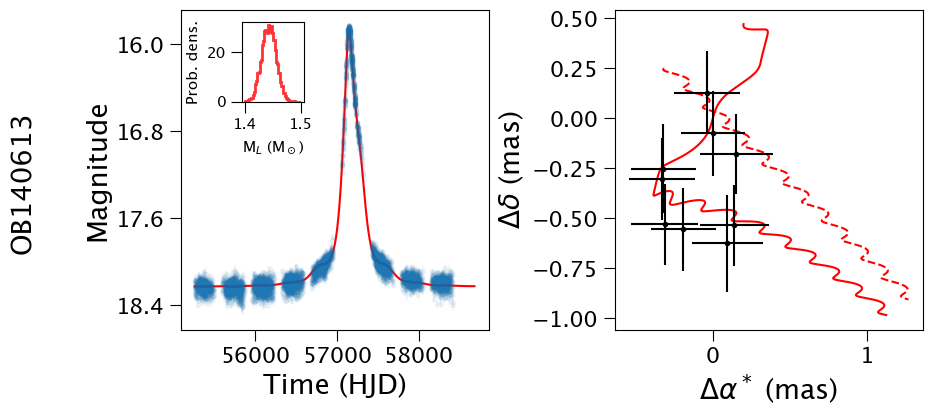

In [225]:
def plot_ob140613_phot_ast():
    mod_root = ob140613_dir + ob140613_id + '_'
    target = 'ob140613'
    mod_yaml = open(mod_root +  'params.yaml').read() 
    params = yaml.safe_load(mod_yaml)

    data = munge.getdata2(target,
                          phot_data=params['phot_data'],
                          ast_data=params['astrom_data'])  
    mod_fit = model_fitter.PSPL_Solver(data, getattr(model, params['model']),
                                             add_error_on_photometry=params['add_error_on_photometry'],
                                             multiply_error_on_photometry=params['multiply_error_on_photometry'],
                                             outputfiles_basename=mod_root)

    mod_all = mod_fit.get_best_fit_modes_model(def_best='maxL')
    tab_all = mod_fit.load_mnest_modes()

    plot_3panel_inset(data, mod_all[0], tab_all[0], target + '_phot_astrom_v3.png', target,
                    r_min_k=4.0, min_max_ast_time=(56500,61000),
                   mass_range=(1.4,1.5)) #, mass_max_lim=4,  log=False

    return
plot_ob140613_phot_ast()

r_min_k =  4.0


/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_73322/3676668089.py:90: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  fm1.get_shared_x_axes().join(fm1, fm2)
/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_73322/3676668089.py:105: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  f1.get_shared_x_axes().join(f1, f2)
/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_73322/3676668089.py:136: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  f3.get_shared_x_axes().join(f3, f4)


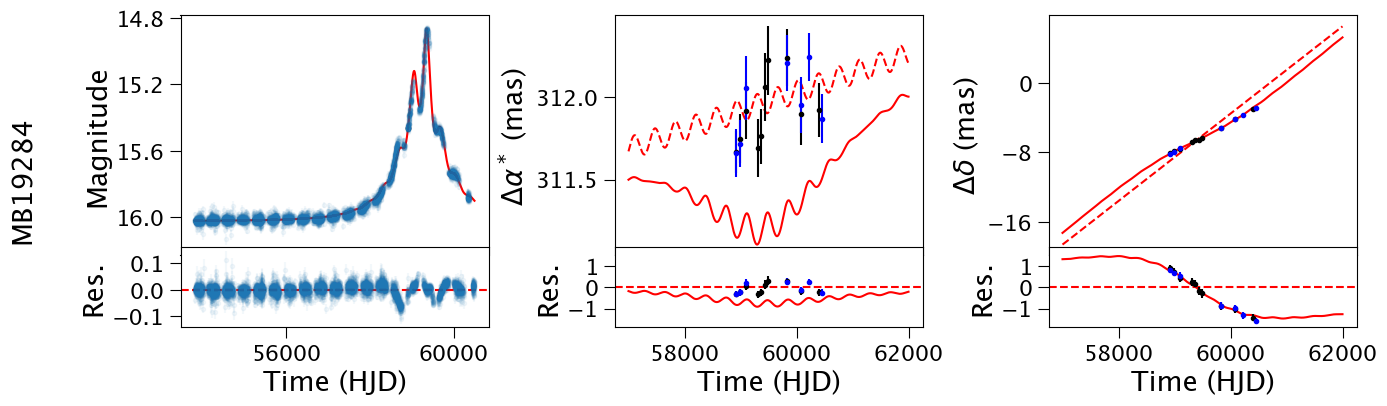

In [191]:
def plot_mb19284_phot_ast():
    mod_root = phot_ast_fits['MB19284']
    target = 'mb19284'    
    mod_yaml = open(mod_root +  'params.yaml').read() 
    params = yaml.safe_load(mod_yaml)

    data = munge.getdata2(target, phot_data=params['phot_data'], ast_data=params['astrom_data'])  

    mod_fit = model_fitter.PSPL_Solver(data, getattr(model, params['model']),
                                             add_error_on_photometry=params['add_error_on_photometry'],
                                             multiply_error_on_photometry=params['multiply_error_on_photometry'],
                                             outputfiles_basename=mod_root)

    mod_all = mod_fit.get_best_fit_modes_model(def_best='maxL')
    tab_all = mod_fit.load_mnest_modes()

    plot_3panel(data, mod_all[0], tab_all[0], target + '_phot_astrom.png', target,
                    r_min_k=4.0, ast2=True, min_max_ast_time = (57000, 62000))#, min_max_phot_time = (56500, 60600))#, mass_max_lim=4, log=False)
    return
    
plot_mb19284_phot_ast()

r_min_k =  4.0


/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_8567/933191230.py:99: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  f1.errorbar(data['xpos1']*1e3 - post0[0], data['ypos1']*1e3 - post0[1],


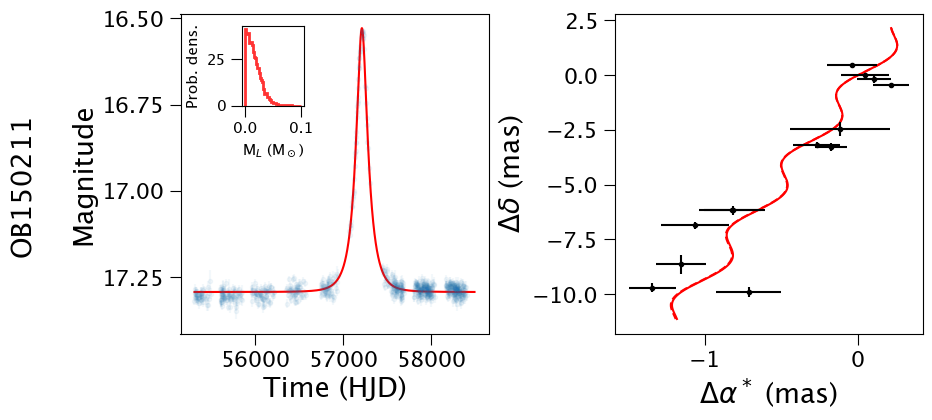

In [24]:
def plot_ob150211_phot_ast():
    mod_root = ob150211_dir + ob150211_id + '_'
    target = 'ob150211'
    
    mod_yaml = open(mod_root +  'params.yaml').read() 
    params = yaml.safe_load(mod_yaml)

    # fit results.
    data = munge.getdata2(target,
                          phot_data=params['phot_data'],
                          ast_data=params['astrom_data'])  

    mod_fit = model_fitter.PSPL_Solver(data,
                                             getattr(model, params['model']),
                                             add_error_on_photometry=params['add_error_on_photometry'],
                                             multiply_error_on_photometry=params['multiply_error_on_photometry'],
                                             outputfiles_basename=mod_root)
    

    mod_all = mod_fit.get_best_fit_modes_model(def_best='maxL')
    tab_all = mod_fit.load_mnest_modes()

    plot_3panel_inset(data, mod_all[0], tab_all[0], target + '_phot_astrom_v3.png', target,
                    r_min_k=4.0, mass_range=(0,0.1))

    return
plot_ob150211_phot_ast()

r_min_k =  4.0


/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_8567/1242355512.py:52: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  fm1.get_shared_x_axes().join(fm1, fm2)
/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_8567/1242355512.py:61: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  f1.get_shared_x_axes().join(f1, f2)
/var/folders/7d/4v5yjgxj5wd6mxjldjpmv9_h00012p/T/ipykernel_8567/1242355512.py:78: MatplotlibDeprecationWarning: The join function was deprecated in Matplotlib 3.6 and will be removed two minor releases later.
  f3.get_shared_x_axes().join(f3, f4)


[-15.71185784  -5.10710555]
[-16.30251703  -5.4684104 ]


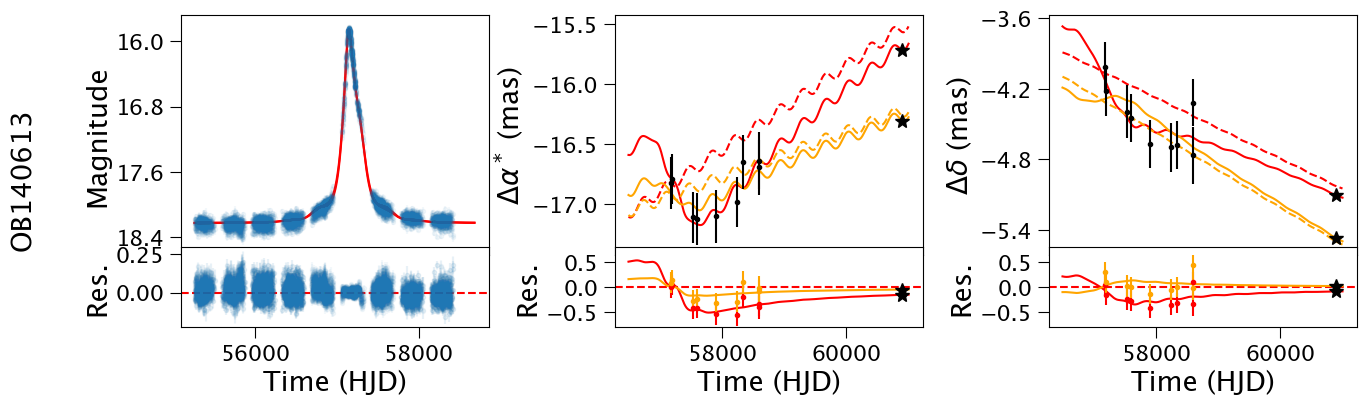

In [135]:
def plot_ob140613_phot_ast():
    mod_root = ob140613_dir + ob140613_id + '_'
    target = 'ob140613'
    mod_yaml = open(mod_root +  'params.yaml').read() 
    params = yaml.safe_load(mod_yaml)

    data = munge.getdata2(target,
                          phot_data=params['phot_data'],
                          ast_data=params['astrom_data'])  
    mod_fit = model_fitter.PSPL_Solver(data, getattr(model, params['model']),
                                             add_error_on_photometry=params['add_error_on_photometry'],
                                             multiply_error_on_photometry=params['multiply_error_on_photometry'],
                                             outputfiles_basename=mod_root)

    mod_all = mod_fit.get_best_fit_modes_model(def_best='maxL')
    tab_all = mod_fit.load_mnest_modes()

    plot_3panel_mult(data, mod_all, tab_all, target + '_phot_astrom_v4.png', target,
                    r_min_k=4.0, min_max_ast_time=(56500,61000),
                   mass_range=(1.4,1.5)) #, mass_max_lim=4,  log=False

    return
plot_ob140613_phot_ast()

In [120]:
mul = (np.hypot(1.55, 0.64) * u.mas/u.year).to(u.rad/u.second)
(mul/u.rad * 3.5*u.kpc).to(u.km/u.second)

<Quantity 27.82305854 km / s>